# BME280 — topologia geografica Edge e workload sperimentale

Il dataset ufficiale del caso di studio è **gennaio 2025** ed è composto da osservazioni Sensor.Community provenienti da sensori BME280 distribuiti a livello mondiale.

L'analisi considera come scenario applicativo l'Europa. La topologia Edge viene quindi derivata dall'intera popolazione di sensori europei con coordinate valide, prima della costruzione del workload sperimentale.

Le coordinate WGS84 vengono proiettate in EPSG:3035 e utilizzate per individuare zone Edge geografiche tramite K-Means. Il numero di cluster viene valutato confrontando più valori di `k` mediante inertia, Silhouette Score e metriche di dispersione geografica.

Solo dopo aver fissato la topologia viene costruito un workload sperimentale di **150 sensori**, distribuito in modo pressoché uniforme tra le zone Edge. La selezione dei sensori all'interno di ciascuna zona è casuale e riproducibile tramite seed fisso.

Il livello Edge effettua elaborazioni locali, mentre il Cloud riceve dati preaggregati e mantiene una vista globale delle diverse zone. Nessun livello Fog viene introdotto in questa fase.

## 0. Preparazione

Da terminale, nella root del progetto:

```powershell
python -m venv .venv
.\.venv\Scripts\Activate.ps1
pip install -r Sensor\notebooks\requirements.txt
jupyter lab

In [1]:
from pathlib import Path
import os

# Workaround per il warning/leak noto di K-Means con MKL su Windows.
# Le variabili devono essere impostate prima di importare NumPy/scikit-learn.
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ['LOKY_MAX_CPU_COUNT'] = '1'

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pyproj import Transformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda value: f'{value:,.3f}')
plt.style.use('seaborn-v0_8-whitegrid')


PROJECT_ROOT = Path.cwd().parent
DATASET_ROOT = PROJECT_ROOT / 'dataset'

PROJECT_ROOT

WindowsPath('C:/Users/aless/GolandProjects/ProgettoSDDC/Sensor')

In [2]:
DATASET_MONTH = '2025-01'
SENSOR_MODEL = 'bmp280'

DATASET_FILENAME = f'{DATASET_MONTH}_{SENSOR_MODEL}.csv'
CSV_SEPARATOR = ';'
SCAN_CHUNK_ROWS = 500_000

TIME_WINDOW_START = pd.Timestamp(f'{DATASET_MONTH}-01T00:00:00Z')
TIME_WINDOW_END = pd.Timestamp('2026-02-01T00:00:00Z')

SCAN_COLUMNS = [
    'sensor_id',
    'lat',
    'lon',
    'timestamp',
]

CSV_PATH = DATASET_ROOT / DATASET_FILENAME


if not CSV_PATH.exists():
    raise FileNotFoundError(
        f'Dataset non trovato: {CSV_PATH}'
    )

if TIME_WINDOW_END <= TIME_WINDOW_START:
    raise ValueError(
        'TIME_WINDOW_END deve essere successivo a TIME_WINDOW_START.'
    )


WINDOW_DAYS = (
    TIME_WINDOW_END - TIME_WINDOW_START
).total_seconds() / 86_400

CSV_PATH

WindowsPath('C:/Users/aless/GolandProjects/ProgettoSDDC/Sensor/dataset/2025-01_bmp280.csv')

## 1. Colonne e anteprima

Prima dell'elaborazione mostriamo la struttura del CSV e alcune righe grezze di esempio.

L'anteprima non viene utilizzata nelle analisi successive e può contenere record esterni alla finestra temporale scelta. Il filtro temporale viene applicato durante la scansione completa del dataset.


In [3]:
dataset_preview = pd.read_csv(
    CSV_PATH,
    sep=CSV_SEPARATOR,
    dtype='string',
    nrows=5,
    low_memory=False,
)

pd.DataFrame({
    'colonna': dataset_preview.columns
})

,colonna
0,sensor_id
1,sensor_type
2,location
3,lat
4,lon
5,timestamp
6,pressure
7,altitude
8,pressure_sealevel
9,temperature


### Prime righe

In [4]:
dataset_preview

,sensor_id,sensor_type,location,lat,lon,timestamp,pressure,altitude,pressure_sealevel,temperature
0,20490,BMP280,10403,54.092,12.122,2025-01-01T01:11:16,101204.63,<NA>,<NA>,7.39
1,66027,BMP280,56312,55.976,37.136,2025-01-01T01:11:16,57634.44,<NA>,<NA>,-135.08
2,88746,BMP280,80339,47.870,18.180,2025-01-01T01:11:20,102149.63,<NA>,<NA>,-2.72
3,62428,BMP280,48466,41.84420463,12.88565612,2025-01-01T01:11:21,97003.63,<NA>,<NA>,10.34
4,46914,BMP280,32660,48.80913350,8.87205580,2025-01-01T01:11:22,97241.97,<NA>,<NA>,0.30


## 2. Scansione e qualità dei dati

Il CSV viene letto a chunk per evitare di caricare l'intero dataset in memoria.

Durante la scansione vengono:

- interpretati e validati i timestamp;
- mantenute soltanto le osservazioni comprese nella finestra temporale configurata;
- validati gli identificativi dei sensori;
- validate le coordinate geografiche;
- accumulate le statistiche necessarie per costruire successivamente una riga per sensore.

In questa fase non viene ancora applicato alcun filtro geografico europeo.


In [5]:
def process_timestamps(chunk, time_start, time_end):
    timestamp_text = (
        chunk['timestamp']
        .str.strip()
        .str.strip("'\"")
    )

    timestamps = pd.to_datetime(
        timestamp_text,
        format='mixed',
        errors='coerce',
        utc=True,
    )

    valid_timestamp = timestamps.notna()

    in_time_window = (
        valid_timestamp
        & timestamps.ge(time_start)
        & timestamps.lt(time_end)
    )

    valid_times = timestamps.loc[valid_timestamp]
    retained_times = timestamps.loc[in_time_window]

    metadata = {
        'invalid_timestamp_rows': int((~valid_timestamp).sum()),
        'outside_time_window_rows': int(
            (valid_timestamp & ~in_time_window).sum()
        ),
        'observed_timestamp_min': (
            valid_times.min() if not valid_times.empty else None
        ),
        'observed_timestamp_max': (
            valid_times.max() if not valid_times.empty else None
        ),
        'retained_timestamp_min': (
            retained_times.min() if not retained_times.empty else None
        ),
        'retained_timestamp_max': (
            retained_times.max() if not retained_times.empty else None
        ),
    }

    filtered_chunk = chunk.loc[in_time_window].copy()

    return filtered_chunk, metadata

In [6]:
NULL_LIKE_VALUES = {
    '',
    'null',
    '<null>',
    'none',
    'nan',
}


def count_valid_column_values(frame):
    counts = {}

    for column_name in frame.columns:
        values = frame[column_name]

        normalized = (
            values
            .astype('string')
            .str.strip()
            .str.lower()
        )

        valid = (
            normalized.notna()
            & ~normalized.isin(NULL_LIKE_VALUES)
        )

        counts[column_name] = int(valid.sum())

    return pd.Series(counts, dtype='int64')

In [7]:
def aggregate_sensor_chunk(chunk):
    sensor_ids = chunk['sensor_id'].str.strip()

    valid_sensor_id = (
        sensor_ids.notna()
        & sensor_ids.ne('')
    )

    latitudes = pd.to_numeric(
        chunk['lat'],
        errors='coerce',
    )

    longitudes = pd.to_numeric(
        chunk['lon'],
        errors='coerce',
    )

    valid_coordinates = (
        latitudes.between(-90, 90)
        & longitudes.between(-180, 180)
        & ~(
            latitudes.abs().lt(0.01)
            & longitudes.abs().lt(0.01)
        )
    ).fillna(False)

    sensor_rows = pd.DataFrame({
        'sensor_id': sensor_ids,
        'lat': latitudes.where(valid_coordinates),
        'lon': longitudes.where(valid_coordinates),
    }).loc[valid_sensor_id]

    sensor_stats = (
        sensor_rows
        .groupby('sensor_id', as_index=False)
        .agg(
            rows=('sensor_id', 'size'),
            coordinate_rows=('lat', 'count'),
            lat_sum=('lat', 'sum'),
            lon_sum=('lon', 'sum'),
        )
    )

    metadata = {
        'invalid_sensor_id_rows': int(
            (~valid_sensor_id).sum()
        ),
        'invalid_coordinate_rows': int(
            (~valid_coordinates).sum()
        ),
    }

    return sensor_stats, metadata

In [8]:
def update_timestamp_bounds(
    current_min,
    current_max,
    new_min,
    new_max,
):
    if new_min is not None:
        current_min = (
            new_min
            if current_min is None
            else min(current_min, new_min)
        )

    if new_max is not None:
        current_max = (
            new_max
            if current_max is None
            else max(current_max, new_max)
        )

    return current_min, current_max

In [9]:
def scan_sensor_dataset(
    csv_path,
    time_start,
    time_end,
    chunk_rows,
    separator,
):
    chunk_aggregates = []

    raw_rows = 0
    retained_rows = 0

    invalid_timestamp_rows = 0
    outside_time_window_rows = 0
    invalid_sensor_id_rows = 0
    invalid_coordinate_rows = 0
    
    column_valid_counts = None
    observed_timestamp_min = None
    observed_timestamp_max = None
    retained_timestamp_min = None
    retained_timestamp_max = None

    for chunk in pd.read_csv(
        csv_path,
        sep=separator,
        dtype='string',
        chunksize=chunk_rows,
        low_memory=False,
    ):
        raw_rows += len(chunk)

        # 1. Parsing timestamp e filtro temporale
        filtered_chunk, time_metadata = process_timestamps(
            chunk=chunk,
            time_start=time_start,
            time_end=time_end,
        )

        invalid_timestamp_rows += (
            time_metadata['invalid_timestamp_rows']
        )

        outside_time_window_rows += (
            time_metadata['outside_time_window_rows']
        )

        observed_timestamp_min, observed_timestamp_max = (
            update_timestamp_bounds(
                observed_timestamp_min,
                observed_timestamp_max,
                time_metadata['observed_timestamp_min'],
                time_metadata['observed_timestamp_max'],
            )
        )

        retained_timestamp_min, retained_timestamp_max = (
            update_timestamp_bounds(
                retained_timestamp_min,
                retained_timestamp_max,
                time_metadata['retained_timestamp_min'],
                time_metadata['retained_timestamp_max'],
            )
        )

        if filtered_chunk.empty:
            continue
        
        retained_rows += len(filtered_chunk)
        
        
        # Profiling delle colonne nella finestra temporale
        chunk_column_counts = count_valid_column_values(
            filtered_chunk
        )
        
        if column_valid_counts is None:
            column_valid_counts = chunk_column_counts
        else:
            column_valid_counts = column_valid_counts.add(
                chunk_column_counts,
                fill_value=0,
            )
        
        
        # 2. Validazione e aggregazione per sensore
        chunk_stats, sensor_metadata = aggregate_sensor_chunk(
            filtered_chunk
        )

        invalid_sensor_id_rows += (
            sensor_metadata['invalid_sensor_id_rows']
        )

        invalid_coordinate_rows += (
            sensor_metadata['invalid_coordinate_rows']
        )

        chunk_aggregates.append(chunk_stats)

    if not chunk_aggregates:
        raise RuntimeError(
            'Nessuna osservazione valida trovata '
            'nella finestra temporale configurata.'
        )

    sensor_chunk_stats = pd.concat(
        chunk_aggregates,
        ignore_index=True,
    )
    
    
    all_null_columns = (
        column_valid_counts[
            column_valid_counts.eq(0)
        ]
        .index
        .tolist()
    )
    
    
    scan_metadata = {
        'raw_rows': raw_rows,
        'retained_rows': retained_rows,
        'invalid_timestamp_rows': invalid_timestamp_rows,
        'outside_time_window_rows': outside_time_window_rows,
        'invalid_sensor_id_rows': invalid_sensor_id_rows,
        'invalid_coordinate_rows': invalid_coordinate_rows,
        'observed_timestamp_min': observed_timestamp_min,
        'observed_timestamp_max': observed_timestamp_max,
        'retained_timestamp_min': retained_timestamp_min,
        'retained_timestamp_max': retained_timestamp_max,
    
        'column_valid_counts': column_valid_counts,
        'all_null_columns': all_null_columns,
    }
    return sensor_chunk_stats, scan_metadata

In [10]:
sensor_chunk_stats, scan_metadata = scan_sensor_dataset(
    csv_path=CSV_PATH,
    time_start=TIME_WINDOW_START,
    time_end=TIME_WINDOW_END,
    chunk_rows=SCAN_CHUNK_ROWS,
    separator=CSV_SEPARATOR,
)

In [11]:
column_quality = pd.DataFrame({
    'column': scan_metadata['column_valid_counts'].index,
    'valid_rows': scan_metadata['column_valid_counts'].values,
})

column_quality['all_null'] = (
    column_quality['valid_rows'].eq(0)
)

column_quality

,column,valid_rows,all_null
0,sensor_id,4076315,False
1,sensor_type,4076315,False
2,location,4076315,False
3,lat,4076315,False
4,lon,4076315,False
5,timestamp,4076315,False
6,pressure,4039309,False
7,altitude,0,True
8,pressure_sealevel,8128,False
9,temperature,4007304,False


In [12]:
scan_metadata['all_null_columns']

['altitude']

In [13]:
ACTIVE_DATASET_COLUMNS = [
    column
    for column in scan_metadata['column_valid_counts'].index
    if column not in scan_metadata['all_null_columns']
]

ACTIVE_DATASET_COLUMNS

['sensor_id',
 'sensor_type',
 'location',
 'lat',
 'lon',
 'timestamp',
 'pressure',
 'pressure_sealevel',
 'temperature']

In [14]:
observed_window_days = (
    scan_metadata['retained_timestamp_max']
    - scan_metadata['retained_timestamp_min']
).total_seconds() / 86_400


dataset_summary = pd.Series({
    'dimensione_csv_GB':
        CSV_PATH.stat().st_size / 1e9,

    'righe_nel_sv_fisico':
        scan_metadata['raw_rows'],

    'righe_nella_finestra_temporale':
        scan_metadata['retained_rows'],

    'righe_timestamp_non_valido':
        scan_metadata['invalid_timestamp_rows'],

    'righe_fuori_finestra_temporale':
        scan_metadata['outside_time_window_rows'],

    'righe_sensor_id_non_valido':
        scan_metadata['invalid_sensor_id_rows'],

    'righe_coordinate_non_valide':
        scan_metadata['invalid_coordinate_rows'],

    'timestamp_minimo_osservato':
        scan_metadata['observed_timestamp_min'],

    'timestamp_massimo_osservato':
        scan_metadata['observed_timestamp_max'],

    'timestamp_minimo_utilizzato':
        scan_metadata['retained_timestamp_min'],

    'timestamp_massimo_utilizzato':
        scan_metadata['retained_timestamp_max'],

    'durata_finestra_configurata_giorni':
        WINDOW_DAYS,

    'durata_effettivamente_osservata_giorni':
        observed_window_days,

    'sensori_unici':
        sensor_chunk_stats['sensor_id'].nunique(),
})

dataset_summary.to_frame('valore')

,valore
dimensione_csv_GB,0.296
righe_nel_sv_fisico,4076315
righe_nella_finestra_temporale,4076315
righe_timestamp_non_valido,0
righe_fuori_finestra_temporale,0
righe_sensor_id_non_valido,0
righe_coordinate_non_valide,15732
timestamp_minimo_osservato,2025-01-01 01:11:16+00:00
timestamp_massimo_osservato,2025-01-29 23:59:57+00:00
timestamp_minimo_utilizzato,2025-01-01 01:11:16+00:00


## 3. Costruzione della popolazione di sensori localizzabili

Le statistiche raccolte nei singoli chunk vengono aggregate per `sensor_id`.

Per ogni sensore vengono calcolati:

- numero totale di osservazioni nella finestra temporale;
- numero di osservazioni con coordinate valide;
- posizione geografica media;
- frequenza media naturale delle osservazioni (`rows_per_day`).

Vengono quindi esclusi soltanto i sensori che non possiedono alcuna coordinata utilizzabile.

Il risultato rappresenta ancora la popolazione **mondiale** dei sensori localizzabili. Il filtro geografico europeo verrà applicato nella sezione successiva.

In [15]:
sensor_stats = (
    sensor_chunk_stats
    .groupby('sensor_id', as_index=False)
    .agg(
        rows=('rows', 'sum'),
        coordinate_rows=('coordinate_rows', 'sum'),
        lat_sum=('lat_sum', 'sum'),
        lon_sum=('lon_sum', 'sum'),
    )
)


sensor_stats['lat'] = (
    sensor_stats['lat_sum']
    / sensor_stats['coordinate_rows']
)

sensor_stats['lon'] = (
    sensor_stats['lon_sum']
    / sensor_stats['coordinate_rows']
)

sensor_stats['rows_per_day'] = (
    sensor_stats['rows']
    / WINDOW_DAYS
)

In [16]:
located_sensors = (
    sensor_stats
    .loc[sensor_stats['coordinate_rows'].gt(0)]
    .dropna(subset=['lat', 'lon'])
    .copy()
    .reset_index(drop=True)
)


sensor_filter_summary = pd.Series({
    'sensori_totali':
        len(sensor_stats),

    'sensori_senza_coordinate_utilizzabili':
        len(sensor_stats) - len(located_sensors),

    'sensori_localizzabili':
        len(located_sensors),
})

sensor_filter_summary.to_frame('valore')

,valore
sensori_totali,269
sensori_senza_coordinate_utilizzabili,1
sensori_localizzabili,268


### Interpretazione

Questa fase serve esclusivamente a costruire una popolazione geografica utilizzabile per la definizione della topologia.

La validazione semantica delle misure di temperatura, umidità e pressione non viene eseguita nel notebook: resterà una responsabilità del servizio Edge durante l'esecuzione del sistema.

Nella sezione successiva la popolazione mondiale dei sensori localizzabili verrà filtrata per ottenere lo scenario europeo.


## 4. Popolazione europea e proiezione geografica

A partire dalla popolazione mondiale dei sensori localizzabili, viene selezionato lo scenario geografico europeo mediante un bounding box esplicito.

In questa fase viene utilizzata l'intera popolazione europea disponibile: nessun sensore viene ancora selezionato per il workload sperimentale.

Le coordinate geografiche WGS84 (`EPSG:4326`) vengono successivamente proiettate in `EPSG:3035`, sistema di riferimento metrico adatto all'analisi spaziale europea. Le coordinate proiettate `x_km` e `y_km` verranno utilizzate in tutte le successive operazioni di clustering.

In [17]:
EUROPE_BOUNDS = {
    'latitude_min': 34.0,
    'latitude_max': 72.0,
    'longitude_min': -25.0,
    'longitude_max': 45.0,
}

GEOGRAPHIC_CRS = 'EPSG:4326'
EUROPE_PROJECTED_CRS = 'EPSG:3035'

EUROPE_TRANSFORMER = Transformer.from_crs(
    GEOGRAPHIC_CRS,
    EUROPE_PROJECTED_CRS,
    always_xy=True,
)

In [18]:
def filter_european_population(frame, bounds):
    in_europe = (
        frame['lat'].between(
            bounds['latitude_min'],
            bounds['latitude_max'],
        )
        & frame['lon'].between(
            bounds['longitude_min'],
            bounds['longitude_max'],
        )
    )

    return (
        frame.loc[in_europe]
        .copy()
        .reset_index(drop=True)
    )


def add_projected_coordinates(frame, transformer):
    projected = frame.copy()

    easting_m, northing_m = transformer.transform(
        projected['lon'].to_numpy(),
        projected['lat'].to_numpy(),
    )

    projected['x_km'] = easting_m / 1_000.0
    projected['y_km'] = northing_m / 1_000.0

    return projected

In [19]:
europe_population = filter_european_population(
    frame=located_sensors,
    bounds=EUROPE_BOUNDS,
)

europe_population = add_projected_coordinates(
    frame=europe_population,
    transformer=EUROPE_TRANSFORMER,
)


assert europe_population['sensor_id'].is_unique

assert europe_population[
    ['lat', 'lon', 'rows', 'rows_per_day', 'x_km', 'y_km']
].notna().all().all()


europe_population_summary = pd.Series({
    'sensori_europei': len(europe_population),
    'latitudine_min': europe_population['lat'].min(),
    'latitudine_max': europe_population['lat'].max(),
    'longitudine_min': europe_population['lon'].min(),
    'longitudine_max': europe_population['lon'].max(),
    'righe_totali': europe_population['rows'].sum(),
    'righe_medie_giornaliere': (
        europe_population['rows_per_day'].sum()
    ),
})

europe_population_summary.to_frame('valore')

,valore
sensori_europei,253.000
latitudine_min,37.404
latitudine_max,60.362
longitudine_min,-8.514
longitudine_max,44.003
righe_totali,"3,866,200.000"
righe_medie_giornaliere,"9,763.131"


## 5. Ricerca del numero di zone Edge

Il clustering viene valutato sull'intera popolazione europea, prima della costruzione del workload sperimentale.

Per ogni valore di `k` compreso tra `K_EDGE_MIN` e `K_EDGE_MAX`, K-Means opera sulle coordinate metriche `x_km` e `y_km`.

La scelta automatica del numero di zone Edge utilizza il **Silhouette Score** come criterio principale: viene selezionato il valore di `k` che massimizza la coesione interna dei cluster e la separazione tra cluster differenti.

L'**elbow method** sull'inertia viene mantenuto come indicatore diagnostico della complessità del clustering, ma non determina direttamente il numero finale di Edge.

Le metriche di distanza (`mean_distance_km`, `p95_distance_km`, `max_radius_km`) e di carico vengono utilizzate come ulteriori diagnostiche della topologia, senza imporre vincoli rigidi.

In [20]:
RANDOM_STATE = 42
KMEANS_N_INIT = 20

K_EDGE_MIN = 5
K_EDGE_MAX = 15

SECONDS_PER_DAY = 86_400

In [21]:
def evaluate_edge_k(frame, k):
    features = frame[
        ['x_km', 'y_km']
    ].to_numpy(dtype=float)

    sensor_load_eps = (
        frame['rows_per_day'].to_numpy(dtype=float)
        / SECONDS_PER_DAY
    )

    model = KMeans(
        n_clusters=k,
        n_init=KMEANS_N_INIT,
        random_state=RANDOM_STATE,
    )

    labels = model.fit_predict(features)
    centroids = model.cluster_centers_

    distances = np.linalg.norm(
        features - centroids[labels],
        axis=1,
    )

    sensor_counts = np.bincount(
        labels,
        minlength=k,
    )

    edge_loads = np.bincount(
        labels,
        weights=sensor_load_eps,
        minlength=k,
    )

    edge_radii = np.array([
        distances[labels == edge].max()
        for edge in range(k)
    ])

    mean_load = edge_loads.mean()

    return {
        'k': k,
        'inertia': model.inertia_,
        'silhouette': silhouette_score(
            features,
            labels,
        ),
        'min_sensors': sensor_counts.min(),
        'mean_sensors': sensor_counts.mean(),
        'max_sensors': sensor_counts.max(),
        'mean_distance_km': distances.mean(),
        'p95_distance_km': np.quantile(
            distances,
            0.95,
        ),
        'max_radius_km': edge_radii.max(),
        'mean_load_eps': mean_load,
        'max_load_eps': edge_loads.max(),
        'load_cv': edge_loads.std() / mean_load,
        'max_load_factor': edge_loads.max() / mean_load,
    }

In [22]:
def detect_elbow(metrics):
    k_values = metrics['k'].to_numpy(dtype=float)
    inertia = metrics['inertia'].to_numpy(dtype=float)

    normalized_k = (
        (k_values - k_values.min())
        / (k_values.max() - k_values.min())
    )

    normalized_inertia = (
        (inertia - inertia.min())
        / (inertia.max() - inertia.min())
    )

    points = np.column_stack([
        normalized_k,
        normalized_inertia,
    ])

    start = points[0]
    end = points[-1]

    line = end - start
    line_length = np.linalg.norm(line)

    offsets = points - start

    distances = np.abs(
        line[0] * offsets[:, 1]
        - line[1] * offsets[:, 0]
    ) / line_length

    elbow_index = int(np.argmax(distances))

    return int(k_values[elbow_index])

In [23]:
edge_k_metrics = pd.DataFrame([
    evaluate_edge_k(
        frame=europe_population,
        k=k,
    )
    for k in range(
        K_EDGE_MIN,
        K_EDGE_MAX + 1,
    )
])


# Elbow mantenuto come diagnostica.
elbow_k = detect_elbow(edge_k_metrics)


# Il numero di Edge viene scelto massimizzando
# il Silhouette Score nell'intervallo esplorato.
best_silhouette_index = (
    edge_k_metrics['silhouette'].idxmax()
)

selected_k_edge = int(
    edge_k_metrics.loc[
        best_silhouette_index,
        'k',
    ]
)

selected_k_metrics = (
    edge_k_metrics.loc[
        edge_k_metrics['k'].eq(selected_k_edge)
    ]
    .iloc[0]
)


print(f'Elbow diagnostico: k={elbow_k}')

print(
    f'Numero Edge selezionato: '
    f'k={selected_k_edge}'
)

print(
    f'Silhouette massima: '
    f'{selected_k_metrics["silhouette"]:.6f}'
)

selected_k_metrics

Elbow diagnostico: k=9
Numero Edge selezionato: k=9
Silhouette massima: 0.512017


k                           9.000
inertia            11,115,636.269
silhouette                  0.512
min_sensors                 4.000
mean_sensors               28.111
max_sensors                46.000
mean_distance_km          168.472
p95_distance_km           417.729
max_radius_km             908.434
mean_load_eps               0.013
max_load_eps                0.022
load_cv                     0.635
max_load_factor             1.729
Name: 4, dtype: float64

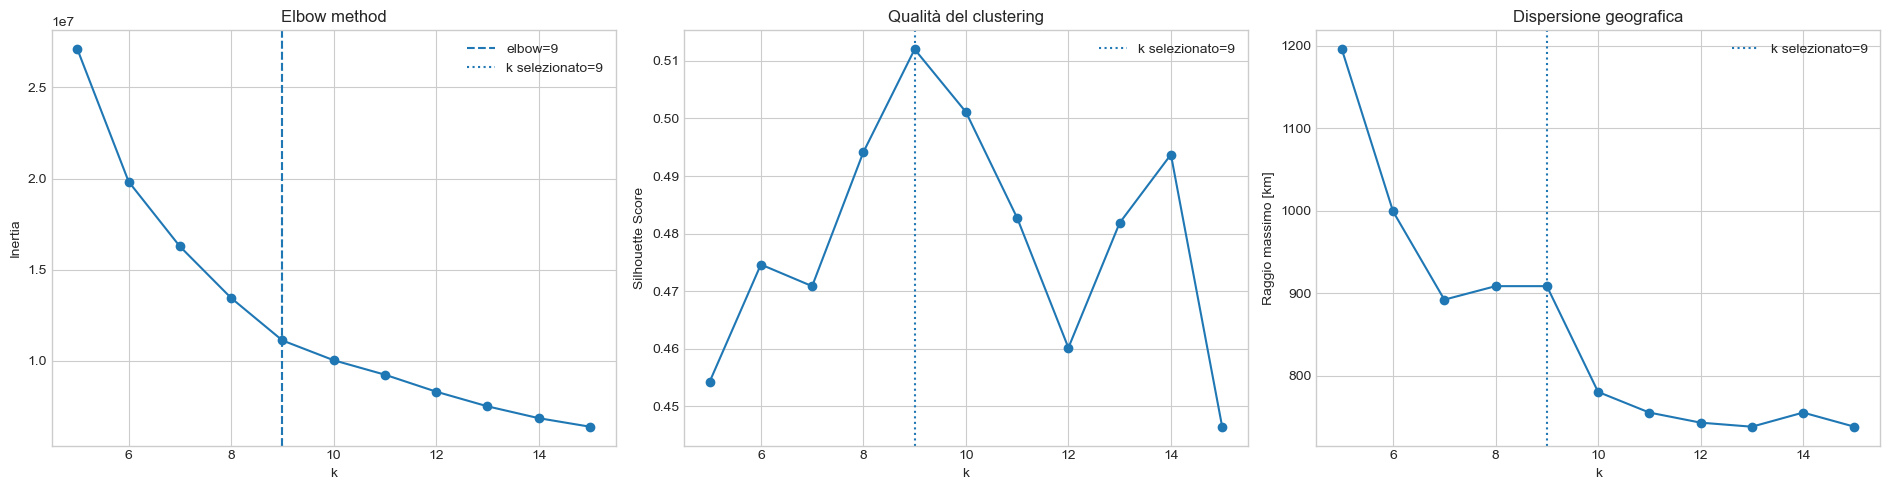

In [24]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(19, 5),
)


# Elbow
axes[0].plot(
    edge_k_metrics['k'],
    edge_k_metrics['inertia'],
    marker='o',
)

axes[0].axvline(
    elbow_k,
    linestyle='--',
    label=f'elbow={elbow_k}',
)

axes[0].axvline(
    selected_k_edge,
    linestyle=':',
    label=f'k selezionato={selected_k_edge}',
)

axes[0].set(
    xlabel='k',
    ylabel='Inertia',
    title='Elbow method',
)

axes[0].legend()


# Silhouette
axes[1].plot(
    edge_k_metrics['k'],
    edge_k_metrics['silhouette'],
    marker='o',
)

axes[1].axvline(
    selected_k_edge,
    linestyle=':',
    label=f'k selezionato={selected_k_edge}',
)

axes[1].set(
    xlabel='k',
    ylabel='Silhouette Score',
    title='Qualità del clustering',
)

axes[1].legend()


# Dispersione geografica
axes[2].plot(
    edge_k_metrics['k'],
    edge_k_metrics['max_radius_km'],
    marker='o',
)

axes[2].axvline(
    selected_k_edge,
    linestyle=':',
    label=f'k selezionato={selected_k_edge}',
)

axes[2].set(
    xlabel='k',
    ylabel='Raggio massimo [km]',
    title='Dispersione geografica',
)

axes[2].legend()


plt.tight_layout()
plt.show()

## 6. Topologia Edge sulla popolazione europea

Dopo la selezione del numero di cluster, K-Means viene eseguito nuovamente sull'intera popolazione europea utilizzando il valore `selected_k_edge`.

Gli identificativi degli Edge vengono stabilizzati ordinando i centroidi da ovest verso est e, a parità di coordinata orizzontale, da sud verso nord.

Ogni sensore riceve quindi:

- un identificativo numerico del cluster;
- un identificativo logico `edge_id`;
- la distanza dal centroide dell'Edge assegnato.

La topologia risultante rappresenta la suddivisione geografica utilizzata dal simulatore e non dipende dal successivo workload sperimentale di 150 sensori.

In [25]:
def stabilize_cluster_labels(
    labels,
    centroids,
):
    centroid_order = np.lexsort((
        centroids[:, 1],
        centroids[:, 0],
    ))

    raw_to_stable = np.empty(
        len(centroids),
        dtype=int,
    )

    raw_to_stable[centroid_order] = np.arange(
        len(centroids)
    )

    stable_labels = raw_to_stable[labels]
    stable_centroids = centroids[centroid_order]

    return stable_labels, stable_centroids

In [26]:
edge_features = (
    europe_population[
        ['x_km', 'y_km']
    ]
    .to_numpy(dtype=float)
)


final_edge_model = KMeans(
    n_clusters=selected_k_edge,
    n_init=KMEANS_N_INIT,
    random_state=RANDOM_STATE,
)

raw_labels = final_edge_model.fit_predict(
    edge_features
)

raw_centroids = final_edge_model.cluster_centers_


stable_labels, stable_centroids = (
    stabilize_cluster_labels(
        labels=raw_labels,
        centroids=raw_centroids,
    )
)

In [27]:
edge_features = (
    europe_population[
        ['x_km', 'y_km']
    ]
    .to_numpy(dtype=float)
)


final_edge_model = KMeans(
    n_clusters=selected_k_edge,
    n_init=KMEANS_N_INIT,
    random_state=RANDOM_STATE,
)

raw_labels = final_edge_model.fit_predict(
    edge_features
)

raw_centroids = final_edge_model.cluster_centers_


stable_labels, stable_centroids = (
    stabilize_cluster_labels(
        labels=raw_labels,
        centroids=raw_centroids,
    )
)

In [28]:
edge_centroids = pd.DataFrame({
    'edge_cluster': np.arange(selected_k_edge),

    'edge_id': [
        f'edge-{edge}'
        for edge in range(selected_k_edge)
    ],

    'centroid_x_km': stable_centroids[:, 0],
    'centroid_y_km': stable_centroids[:, 1],
})


europe_topology = europe_population.copy()

europe_topology['edge_cluster'] = stable_labels

europe_topology['edge_id'] = [
    f'edge-{edge}'
    for edge in stable_labels
]

europe_topology['distance_to_edge_km'] = (
    np.linalg.norm(
        edge_features
        - stable_centroids[stable_labels],
        axis=1,
    )
)


# Valore neutro richiesto temporaneamente
# dal parser Go corrente.
UNASSIGNED_MACROAREA_ID = 'none'

europe_topology['macroarea_id'] = (
    UNASSIGNED_MACROAREA_ID
)


assert len(europe_topology) == len(europe_population)
assert europe_topology['sensor_id'].is_unique
assert europe_topology['edge_id'].notna().all()

europe_topology.head()

,sensor_id,rows,coordinate_rows,lat_sum,lon_sum,lat,lon,rows_per_day,x_km,y_km,edge_cluster,edge_id,distance_to_edge_km,macroarea_id
0,15170,16217,16217,"768,783.102","138,493.180",47.406,8.540,40.952,"4,210.731","2,700.242",3,edge-3,203.271,none
1,1532,9990,9990,"531,168.300","82,017.900",53.170,8.210,25.227,"4,201.302","3,341.668",5,edge-5,213.952,none
2,15360,16496,16496,"818,135.616","182,610.720",49.596,11.070,41.657,"4,398.366","2,943.145",3,edge-3,123.229,none
3,16759,15962,15962,"819,584.852","197,864.952",51.346,12.396,40.308,"4,487.906","3,139.972",5,edge-5,186.006,none
4,17716,12987,12987,"641,895.462","145,220.634",49.426,11.182,32.795,"4,406.762","2,924.367",3,edge-3,124.092,none


In [29]:
edge_population_summary = (
    europe_topology
    .groupby(
        ['edge_cluster', 'edge_id'],
        as_index=False,
    )
    .agg(
        sensors=('sensor_id', 'nunique'),
        rows=('rows', 'sum'),
        rows_per_day=('rows_per_day', 'sum'),

        mean_distance_km=(
            'distance_to_edge_km',
            'mean',
        ),

        p95_distance_km=(
            'distance_to_edge_km',
            lambda values: values.quantile(0.95),
        ),

        max_radius_km=(
            'distance_to_edge_km',
            'max',
        ),
    )
    .merge(
        edge_centroids,
        on=['edge_cluster', 'edge_id'],
        how='left',
        validate='one_to_one',
    )
)


edge_population_summary[
    'natural_events_per_second'
] = (
    edge_population_summary['rows_per_day']
    / SECONDS_PER_DAY
)


edge_population_summary['load_share_pct'] = (
    100
    * edge_population_summary['natural_events_per_second']
    / edge_population_summary[
        'natural_events_per_second'
    ].sum()
)


edge_population_summary = (
    edge_population_summary[[
        'edge_id',
        'sensors',
        'rows',
        'rows_per_day',
        'natural_events_per_second',
        'load_share_pct',
        'mean_distance_km',
        'p95_distance_km',
        'max_radius_km',
        'centroid_x_km',
        'centroid_y_km',
        'edge_cluster',
    ]]
    .sort_values(
        'edge_cluster'
    )
    .reset_index(drop=True)
)

edge_population_summary

,edge_id,sensors,rows,rows_per_day,natural_events_per_second,load_share_pct,mean_distance_km,p95_distance_km,max_radius_km,centroid_x_km,centroid_y_km,edge_cluster
0,edge-0,8,110560,279.192,0.003,2.860,409.860,596.532,671.896,"3,507.915","2,503.311",0
1,edge-1,16,245984,621.172,0.007,6.362,190.010,394.321,451.452,"3,515.406","3,341.386",1
2,edge-2,46,742908,"1,876.030",0.022,19.215,106.477,189.756,239.699,"4,039.117","3,180.425",2
3,edge-3,44,742243,"1,874.351",0.022,19.198,129.984,243.680,288.009,"4,288.048","2,888.235",3
4,edge-4,12,141600,357.576,0.004,3.663,218.712,451.412,511.596,"4,362.100","2,327.663",4
5,edge-5,43,674478,"1,703.227",0.020,17.446,192.351,303.092,908.434,"4,412.927","3,310.197",5
6,edge-6,37,538332,"1,359.424",0.016,13.924,175.612,297.455,437.813,"4,932.841","3,065.104",6
7,edge-7,43,622608,"1,572.242",0.018,16.104,178.506,538.892,609.855,"5,385.697","2,274.291",7
8,edge-8,4,47487,119.917,0.001,1.228,154.500,278.689,307.176,"6,078.115","4,013.440",8


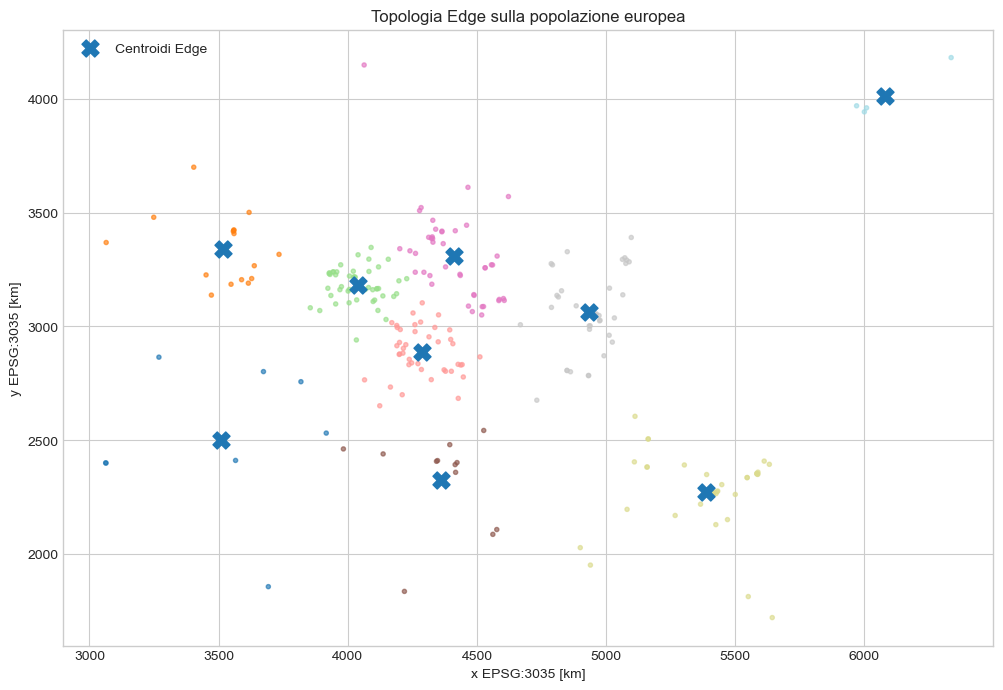

In [30]:
fig, ax = plt.subplots(
    figsize=(12, 8)
)

cmap = plt.get_cmap(
    'tab20',
    selected_k_edge,
)

ax.scatter(
    europe_topology['x_km'],
    europe_topology['y_km'],
    c=europe_topology['edge_cluster'],
    cmap=cmap,
    s=9,
    alpha=0.65,
)

ax.scatter(
    edge_centroids['centroid_x_km'],
    edge_centroids['centroid_y_km'],
    marker='X',
    s=150,
    label='Centroidi Edge',
)

ax.set(
    xlabel='x EPSG:3035 [km]',
    ylabel='y EPSG:3035 [km]',
    title='Topologia Edge sulla popolazione europea',
)

ax.legend()

plt.show()

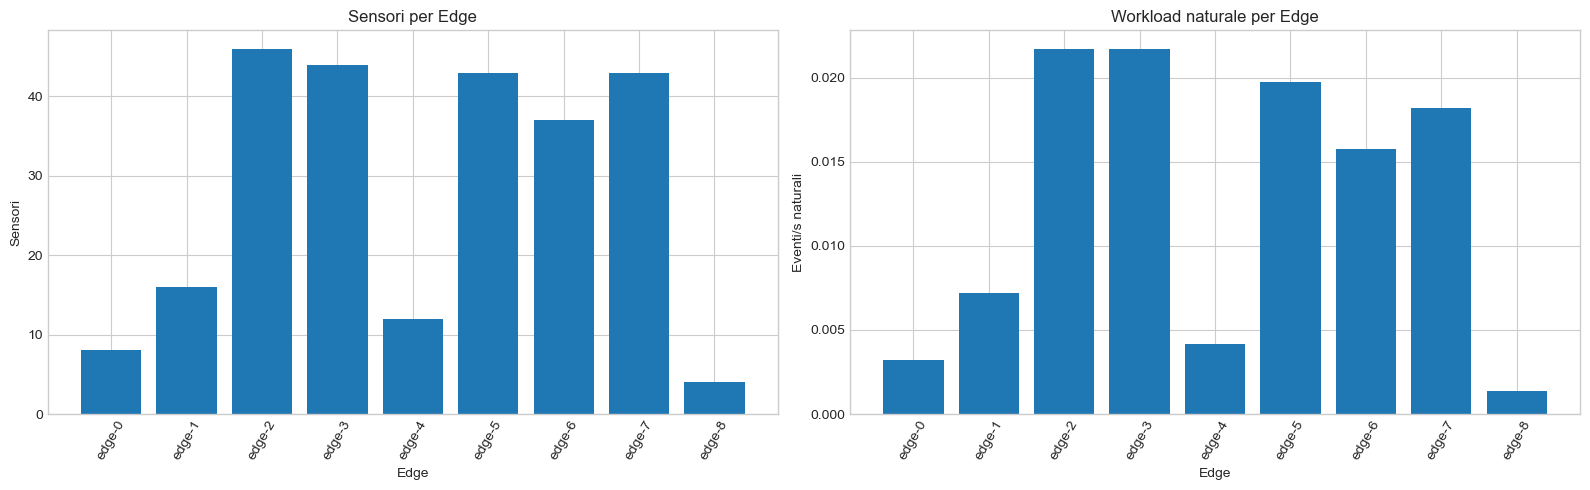

In [31]:
edge_plot = (
    edge_population_summary
    .sort_values('edge_cluster')
)


fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 5),
)


axes[0].bar(
    edge_plot['edge_id'],
    edge_plot['sensors'],
)

axes[0].set(
    xlabel='Edge',
    ylabel='Sensori',
    title='Sensori per Edge',
)

axes[0].tick_params(
    axis='x',
    rotation=60,
)


axes[1].bar(
    edge_plot['edge_id'],
    edge_plot['natural_events_per_second'],
)

axes[1].set(
    xlabel='Edge',
    ylabel='Eventi/s naturali',
    title='Workload naturale per Edge',
)

axes[1].tick_params(
    axis='x',
    rotation=60,
)


plt.tight_layout()
plt.show()

## 7. Costruzione del workload sperimentale a copertura bilanciata

Dopo aver fissato la topologia sulla popolazione europea completa, viene costruito il workload utilizzato negli esperimenti del simulatore.

Il workload contiene `EXPERIMENT_SENSOR_COUNT` sensori e non ha lo scopo di riprodurre proporzionalmente la densità originale di Sensor.Community. L'obiettivo è rappresentare tutti i domini Edge con un numero comparabile di dispositivi, evitando che le zone geograficamente più dense dominino automaticamente gli esperimenti.

La quota di base viene ottenuta dividendo il numero totale di sensori sperimentali per il numero di Edge. Gli eventuali posti rimanenti vengono assegnati agli Edge con popolazione maggiore.

All'interno di ogni Edge i sensori vengono selezionati casualmente senza sostituzione utilizzando `RANDOM_STATE`, rendendo la selezione riproducibile.

Il bilanciamento riguarda quindi il numero di sensori assegnati ai diversi Edge; il rate effettivo di eventi viene misurato separatamente nella sezione successiva.

In [32]:
EXPERIMENT_SENSOR_COUNT = 150

In [33]:
def allocate_balanced_quotas(
    population_by_edge,
    workload_size,
):
    allocation = (
        population_by_edge
        .sort_values('edge_cluster')
        .copy()
        .reset_index(drop=True)
    )

    n_edges = len(allocation)

    if n_edges > workload_size:
        raise ValueError(
            f'Impossibile rappresentare {n_edges} Edge '
            f'con soli {workload_size} sensori.'
        )

    total_population = allocation[
        'population_sensors'
    ].sum()

    if workload_size > total_population:
        raise ValueError(
            'Il workload richiesto supera '
            'la popolazione disponibile.'
        )

    base_quota = workload_size // n_edges
    remainder = workload_size % n_edges

    allocation['sensor_quota'] = base_quota

    if (
        allocation['population_sensors']
        < allocation['sensor_quota']
    ).any():
        raise RuntimeError(
            'Almeno un Edge non contiene abbastanza '
            'sensori per la quota richiesta.'
        )

    # I sensori residui vengono assegnati
    # agli Edge con popolazione maggiore.
    extra_indices = (
        allocation
        .loc[
            allocation['population_sensors']
            > base_quota
        ]
        .sort_values(
            ['population_sensors', 'edge_cluster'],
            ascending=[False, True],
        )
        .head(remainder)
        .index
    )

    if len(extra_indices) != remainder:
        raise RuntimeError(
            'Impossibile distribuire tutte '
            'le quote aggiuntive.'
        )

    allocation.loc[
        extra_indices,
        'sensor_quota',
    ] += 1

    if (
        allocation['sensor_quota']
        > allocation['population_sensors']
    ).any():
        raise RuntimeError(
            'Una quota supera la popolazione '
            'disponibile del relativo Edge.'
        )

    return allocation

In [34]:
population_by_edge = (
    europe_topology
    .groupby(
        ['edge_cluster', 'edge_id'],
        as_index=False,
    )
    .agg(
        population_sensors=(
            'sensor_id',
            'nunique',
        )
    )
)


edge_workload_quotas = allocate_balanced_quotas(
    population_by_edge=population_by_edge,
    workload_size=EXPERIMENT_SENSOR_COUNT,
)


assert (
    edge_workload_quotas['sensor_quota'].sum()
    == EXPERIMENT_SENSOR_COUNT
)

assert (
    edge_workload_quotas['sensor_quota']
    <= edge_workload_quotas['population_sensors']
).all()


edge_workload_quotas

RuntimeError: Almeno un Edge non contiene abbastanza sensori per la quota richiesta.

In [ ]:
rng = np.random.default_rng(RANDOM_STATE)

workload_parts = []


for quota in edge_workload_quotas.itertuples(
    index=False
):
    edge_members = europe_topology.loc[
        europe_topology['edge_id'].eq(
            quota.edge_id
        )
    ]

    selected_indices = rng.choice(
        edge_members.index.to_numpy(),
        size=int(quota.sensor_quota),
        replace=False,
    )

    workload_parts.append(
        edge_members.loc[selected_indices].copy()
    )


experimental_workload = (
    pd.concat(
        workload_parts,
        ignore_index=True,
    )
    .sort_values('sensor_id')
    .reset_index(drop=True)
)


assert (
    len(experimental_workload)
    == EXPERIMENT_SENSOR_COUNT
)

assert (
    experimental_workload['sensor_id'].nunique()
    == EXPERIMENT_SENSOR_COUNT
)

assert (
    experimental_workload['edge_id']
    .notna()
    .all()
)


experimental_workload.head()

In [ ]:
workload_topology_check = (
    experimental_workload[
        ['sensor_id', 'edge_id']
    ]
    .merge(
        europe_topology[
            ['sensor_id', 'edge_id']
        ],
        on='sensor_id',
        suffixes=(
            '_workload',
            '_population',
        ),
        validate='one_to_one',
    )
)


assert (
    workload_topology_check['edge_id_workload']
    == workload_topology_check['edge_id_population']
).all()

In [ ]:
selected_sensors_by_edge = (
    experimental_workload
    .groupby('edge_id', as_index=False)
    .agg(
        selected_sensors=(
            'sensor_id',
            'nunique',
        )
    )
)


workload_by_edge = (
    edge_workload_quotas
    .merge(
        selected_sensors_by_edge,
        on='edge_id',
        how='left',
        validate='one_to_one',
    )
)


workload_by_edge['population_share_pct'] = (
    100
    * workload_by_edge['population_sensors']
    / workload_by_edge['population_sensors'].sum()
)


workload_by_edge['workload_share_pct'] = (
    100
    * workload_by_edge['selected_sensors']
    / EXPERIMENT_SENSOR_COUNT
)


assert (
    workload_by_edge['selected_sensors'].sum()
    == EXPERIMENT_SENSOR_COUNT
)

assert (
    workload_by_edge['selected_sensors']
    == workload_by_edge['sensor_quota']
).all()


workload_by_edge = (
    workload_by_edge[[
        'edge_id',
        'population_sensors',
        'population_share_pct',
        'sensor_quota',
        'selected_sensors',
        'workload_share_pct',
        'edge_cluster',
    ]]
    .sort_values('edge_cluster')
    .reset_index(drop=True)
)


workload_by_edge

In [ ]:
fig, ax = plt.subplots(figsize=(13, 5))

positions = np.arange(
    len(workload_by_edge)
)

width = 0.4


ax.bar(
    positions - width / 2,
    workload_by_edge['population_share_pct'],
    width,
    label='Popolazione europea',
)

ax.bar(
    positions + width / 2,
    workload_by_edge['workload_share_pct'],
    width,
    label='Workload sperimentale',
)


ax.set_xticks(
    positions,
    workload_by_edge['edge_id'],
    rotation=60,
)

ax.set(
    ylabel='Quota sensori [%]',
    title='Popolazione europea e workload sperimentale',
)

ax.legend()

plt.tight_layout()
plt.show()

## 8. Analisi del replay sperimentale

Il rate naturale viene calcolato esclusivamente sui sensori appartenenti al workload sperimentale.

Poiché il numero di sensori per Edge è bilanciato ma la frequenza di osservazione dei singoli dispositivi può variare, il carico effettivo viene misurato utilizzando `rows_per_day`.

Vengono inoltre calcolati alcuni scenari di accelerazione del replay e il fattore necessario per raggiungere il target sperimentale complessivo.

In [ ]:
TARGET_EXPERIMENT_EVENTS_PER_SECOND = 2_500

REPLAY_FACTORS = [
    1,
    100,
    1_000,
]

In [ ]:
workload_edge_summary = (
    experimental_workload
    .groupby(
        ['edge_cluster', 'edge_id'],
        as_index=False,
    )
    .agg(
        sensors=('sensor_id', 'nunique'),
        rows=('rows', 'sum'),
        rows_per_day=('rows_per_day', 'sum'),
    )
)


workload_edge_summary[
    'natural_events_per_second'
] = (
    workload_edge_summary['rows_per_day']
    / SECONDS_PER_DAY
)


natural_replay_events_per_second = (
    workload_edge_summary[
        'natural_events_per_second'
    ].sum()
)


workload_edge_summary['load_share_pct'] = (
    100
    * workload_edge_summary[
        'natural_events_per_second'
    ]
    / natural_replay_events_per_second
)


workload_edge_summary[
    'target_events_per_second'
] = (
    TARGET_EXPERIMENT_EVENTS_PER_SECOND
    * workload_edge_summary['load_share_pct']
    / 100
)


workload_edge_summary = (
    workload_edge_summary
    .sort_values('edge_cluster')
    .reset_index(drop=True)
)


workload_edge_summary

In [ ]:
required_replay_factor = (
    TARGET_EXPERIMENT_EVENTS_PER_SECOND
    / natural_replay_events_per_second
)


replay_load_scenarios = pd.DataFrame({
    'replay_factor': REPLAY_FACTORS,
    'total_events_per_second': [
        natural_replay_events_per_second * factor
        for factor in REPLAY_FACTORS
    ],
})


print(
    'Rate naturale del workload [events/s]:',
    natural_replay_events_per_second,
)

print(
    'Replay factor richiesto per '
    f'{TARGET_EXPERIMENT_EVENTS_PER_SECOND} events/s:',
    required_replay_factor,
)

replay_load_scenarios

## 9. Esportazione degli artefatti

Gli artefatti esportati distinguono chiaramente:

- la topologia derivata dall'intera popolazione europea;
- il workload sperimentale di 150 sensori;
- le metriche utilizzate per scegliere il numero di Edge;
- il carico naturale e gli scenari di replay.

Il campo `macroarea_id` viene mantenuto temporaneamente con valore `none` esclusivamente per compatibilità con il parser Go corrente. Non rappresenta un livello Fog reale dell'architettura.

In [ ]:
OUTPUT_DIR = (
    DATASET_ROOT
    / 'output'
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


experimental_topology = (
    experimental_workload[[
        'sensor_id',
        'macroarea_id',
        'edge_id',
        'lat',
        'lon',
        'x_km',
        'y_km',
        'rows',
        'rows_per_day',
        'distance_to_edge_km',
    ]]
    .sort_values('sensor_id')
    .reset_index(drop=True)
)


assert (
    len(experimental_topology)
    == EXPERIMENT_SENSOR_COUNT
)

assert (
    experimental_topology['sensor_id'].nunique()
    == EXPERIMENT_SENSOR_COUNT
)

assert (
    experimental_topology['macroarea_id']
    .eq(UNASSIGNED_MACROAREA_ID)
    .all()
)

In [ ]:
edge_k_metrics.to_csv(
    OUTPUT_DIR / 'edge_k_metrics.csv',
    index=False,
)


edge_population_summary.to_csv(
    OUTPUT_DIR / 'edge_population_summary.csv',
    index=False,
)


edge_centroids.to_csv(
    OUTPUT_DIR / 'edge_centroids.csv',
    index=False,
)


europe_topology[[
    'sensor_id',
    'macroarea_id',
    'edge_cluster',
    'edge_id',
    'lat',
    'lon',
    'x_km',
    'y_km',
    'rows',
    'rows_per_day',
    'distance_to_edge_km',
]].to_csv(
    OUTPUT_DIR / 'europe_topology.csv',
    index=False,
)


workload_by_edge.to_csv(
    OUTPUT_DIR / 'workload_by_edge.csv',
    index=False,
)


workload_edge_summary.to_csv(
    OUTPUT_DIR / 'workload_edge_summary.csv',
    index=False,
)


# Nome mantenuto per compatibilità con il simulatore Go.
experimental_topology.to_csv(
    OUTPUT_DIR / 'kmeans_topology.csv',
    index=False,
)


replay_load_scenarios.to_csv(
    OUTPUT_DIR / 'replay_load_scenarios.csv',
    index=False,
)


EXPORTED_ARTIFACTS = [
    'edge_k_metrics.csv',
    'edge_population_summary.csv',
    'edge_centroids.csv',
    'europe_topology.csv',
    'workload_by_edge.csv',
    'workload_edge_summary.csv',
    'kmeans_topology.csv',
    'replay_load_scenarios.csv',
]


EXPORTED_ARTIFACTS

### Materializzazione del dataset di replay

A partire dagli identificativi dei sensori selezionati viene generato un CSV fisico ridotto contenente esclusivamente le osservazioni appartenenti al workload sperimentale e alla finestra temporale configurata.

Questo file costituisce la trace effettivamente letta dal simulatore.

In [ ]:
selected_sensor_ids = set(
    experimental_workload[
        'sensor_id'
    ].astype(str)
)


workload_rows = int(
    experimental_workload['rows'].sum()
)

window_rows = int(
    scan_metadata['retained_rows']
)

physical_csv_rows = int(
    scan_metadata['raw_rows']
)


retained_rows_pct = (
    100
    * workload_rows
    / window_rows
)


estimated_window_bytes = (
    CSV_PATH.stat().st_size
    * window_rows
    / physical_csv_rows
)


estimated_workload_bytes = (
    CSV_PATH.stat().st_size
    * workload_rows
    / physical_csv_rows
)


workload_reduction_summary = pd.Series({
    'sensori_totali':
        len(sensor_stats),

    'sensori_localizzabili_globali':
        len(located_sensors),

    'sensori_europei':
        len(europe_population),

    'sensori_workload':
        EXPERIMENT_SENSOR_COUNT,

    'righe_csv_fisico':
        physical_csv_rows,

    'righe_finestra_temporale':
        window_rows,

    'righe_workload':
        workload_rows,

    'righe_workload_su_finestra_pct':
        retained_rows_pct,

    'riduzione_righe_pct':
        100 - retained_rows_pct,

    'dimensione_csv_fisico_GB':
        CSV_PATH.stat().st_size / 1e9,

    'dimensione_finestra_stimata_GB':
        estimated_window_bytes / 1e9,

    'dimensione_workload_stimata_GB':
        estimated_workload_bytes / 1e9,
})


workload_reduction_summary.to_frame('valore')

In [ ]:
MATERIALIZE_REPLAY_CSV = True

MATERIALIZE_CHUNK_ROWS = 1_000_000


REPLAY_CSV_PATH = (
    DATASET_ROOT
    / 'derived'
    / (
        f'{DATASET_MONTH}_{SENSOR_MODEL}_europe_'
        f'sensors-{EXPERIMENT_SENSOR_COUNT}_'
        f'seed-{RANDOM_STATE}.csv'
    )
)


if MATERIALIZE_REPLAY_CSV:
    REPLAY_CSV_PATH.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    written_rows = 0
    first_chunk = True

    for chunk in pd.read_csv(
        CSV_PATH,
        sep=CSV_SEPARATOR,
        dtype={'sensor_id': str},
        chunksize=MATERIALIZE_CHUNK_ROWS,
        low_memory=False,
    ):
        timestamp_text = (
            chunk['timestamp']
            .astype('string')
            .str.strip()
            .str.strip("'\"")
        )

        timestamps = pd.to_datetime(
            timestamp_text,
            format='mixed',
            errors='coerce',
            utc=True,
        )

        in_time_window = (
            timestamps.ge(TIME_WINDOW_START)
            & timestamps.lt(TIME_WINDOW_END)
        ).fillna(False)

        sensor_ids = (
            chunk['sensor_id']
            .astype('string')
            .str.strip()
        )

        selected_chunk = chunk.loc[
            in_time_window
            & sensor_ids.isin(selected_sensor_ids),
            ACTIVE_DATASET_COLUMNS,
        ]

        selected_chunk.to_csv(
            REPLAY_CSV_PATH,
            sep=CSV_SEPARATOR,
            index=False,
            mode='w' if first_chunk else 'a',
            header=first_chunk,
        )

        written_rows += len(selected_chunk)
        first_chunk = False


    assert written_rows == workload_rows


    replay_dataset_summary = pd.Series({
        'path': str(REPLAY_CSV_PATH),
        'rows': written_rows,
        'size_GB': (
            REPLAY_CSV_PATH.stat().st_size
            / 1e9
        ),
    })

else:
    replay_dataset_summary = pd.Series({
        'status': 'non generato'
    })


replay_dataset_summary.to_frame('valore')

## 10. Interpretazione architetturale

- La topologia Edge viene derivata dall'intera popolazione europea prima della costruzione del workload sperimentale.

- Il workload sperimentale contiene 150 sensori distribuiti in modo pressoché uniforme tra gli Edge. Questa scelta controlla il numero di dispositivi per dominio, ma non forza lo stesso rate di eventi, che viene invece misurato separatamente.

- I sensori selezionati ereditano l'assegnazione Edge calcolata sulla popolazione completa e non vengono sottoposti a un nuovo clustering.

- Le metriche di distanza e raggio descrivono la dispersione geografica dei cluster, ma non costituiscono vincoli rigidi sulla topologia.

- `edge_population_summary.csv` descrive la popolazione europea completa e il relativo workload naturale. Non rappresenta la capacità computazionale degli Edge, che verrà misurata successivamente mediante benchmark del servizio Go.

- Il CSV di replay contiene esclusivamente le osservazioni dei sensori appartenenti al workload sperimentale e costituisce la trace utilizzata dal simulatore.

- Il Cloud riceverà dati preaggregati dai diversi Edge e manterrà una vista globale del sistema.

- Nessun livello Fog viene implementato nell'architettura corrente. Il valore `macroarea_id = none` è mantenuto esclusivamente per compatibilità temporanea con il parser Go.